# 多智能体（multi_agent_collaboration）实战

## 1.使用不同的大模型运行多智能体，对比结果并评选 gpt-4o 之下最好的大模型，将所有的大模型和最终结果生成一张表格；

In [1]:
import getpass
import os

# 定义一个帮助函数来检查环境变量，如果不存在则提示用户输入
def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"请输入您的 {var}")

# 设置 OpenAI 和 Langchain API 密钥
_set_if_undefined("OPENAI_API_KEY")
_set_if_undefined("GLM_API_KEY")
_set_if_undefined("DEEPSEEK_API_KEY")
_set_if_undefined("LANGCHAIN_API_KEY")
_set_if_undefined("TAVILY_API_KEY")

# 可选：在 LangSmith 中添加追踪功能
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Multi-agent Collaboration"

In [41]:
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.graph import END, StateGraph, START


# 创建智能体的函数，绑定 LLM（大型语言模型） 和工具
def create_agent(llm, tools, system_message: str):
    """创建一个智能体。"""
    # 定义智能体的提示模板，包含系统消息和工具信息
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI assistant, collaborating with other assistants."
                " Use the provided tools to progress towards answering the question."
                " If you are unable to fully answer, that's OK, another assistant with different tools "
                " will help where you left off. Execute what you can to make progress."
                " If you or any of the other assistants have the final answer or deliverable,"
                " prefix your response with FINAL ANSWER so the team knows to stop."
                " You have access to the following tools: {tool_names}.\n{system_message}",
            ),
            MessagesPlaceholder(variable_name="messages"),  # 用于替换的消息占位符
        ]
    )
    
    # 将系统消息部分和工具名称插入到提示模板中
    prompt = prompt.partial(system_message=system_message)
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
    
    # 将提示模板与语言模型和工具绑定
    return prompt | llm.bind_tools(tools)

In [42]:
from typing import Annotated

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

# Tavily 搜索工具，用于搜索最多 5 条结果
tavily_tool = TavilySearchResults(max_results=5)

# Python REPL 工具，用于执行 Python 代码
repl = PythonREPL()

@tool
def python_repl(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"

    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"

    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

In [43]:
import functools
from langchain_core.messages import AIMessage
from langchain_openai import ChatOpenAI

# 辅助函数：为智能体创建一个节点
def agent_node(state, agent, name):
    # 调用智能体，获取结果
    result = agent.invoke(state)
    
    # 将智能体的输出转换为适合追加到全局状态的格式
    if isinstance(result, ToolMessage):
        pass  # 如果是工具消息，跳过处理
    else:
        # 将结果转换为 AIMessage，并排除部分字段
        result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)
    
    # 返回更新后的状态，包括消息和发送者
    return {
        "messages": [result],  # 包含新生成的消息
        # 我们使用严格的工作流程，通过记录发送者来知道接下来传递给谁
        "sender": name,
    }

In [44]:
# 为 Agent 配置各自的大模型
# research_llm = ChatOpenAI(model="glm-4-plus", api_key=os.getenv("GLM_API_KEY"), base_url=os.getenv("GLM_BASE_URL"))
# chart_llm = ChatOpenAI(model="glm-4-plus", api_key=os.getenv("GLM_API_KEY"), base_url=os.getenv("GLM_BASE_URL"))

In [45]:
research_llm = ChatOpenAI(model="qwen-plus", api_key=os.getenv("DASHSCOPE_API_KEY"), base_url=os.getenv("DASHSCOPE_BASE_URL"))
chart_llm = ChatOpenAI(model="qwen-plus", api_key=os.getenv("DASHSCOPE_API_KEY"), base_url=os.getenv("DASHSCOPE_BASE_URL"))

In [46]:
# research_llm = ChatOpenAI(model="gpt-4o-mini")
# chart_llm = ChatOpenAI(model="gpt-4o-mini")

In [47]:
# research_llm = ChatOpenAI(model="deepseek-chat", api_key=os.getenv("DEEPSEEK_API_KEY"), base_url=os.getenv("DEEPSEEK_BASE_URL"))
# chart_llm = ChatOpenAI(model="deepseek-chat", api_key=os.getenv("DEEPSEEK_API_KEY"), base_url=os.getenv("DEEPSEEK_BASE_URL"))

In [48]:
# 研究智能体及其节点
research_agent = create_agent(
    research_llm,  # 使用 research_llm 作为研究智能体的语言模型
    [tavily_tool],  # 研究智能体使用 Tavily 搜索工具
    system_message="Before using the search engine, carefully think through and clarify the query. "
    "Then, conduct a single search that addresses all aspects of the query in one go.",  # 系统消息，指导智能体如何使用搜索工具
)

In [49]:
# 使用 functools.partial 创建研究智能体的节点，指定该节点的名称为 "Researcher"
research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")

In [50]:
chart_agent = create_agent(
    chart_llm,  # 使用 chart_llm 作为图表生成器智能体的语言模型
    [python_repl],  # 图表生成器智能体使用 Python REPL 工具
    system_message="Create clear and user-friendly charts based on the provided data.",  # 系统消息，指导智能体如何生成图表
)

In [51]:
# 使用 functools.partial 创建图表生成器智能体的节点，指定该节点的名称为 "Chart_Generator"
chart_node = functools.partial(agent_node, agent=chart_agent, name="Chart_Generator")

In [52]:
from langgraph.prebuilt import ToolNode

# 定义工具列表，包括 Tavily 搜索工具和 Python REPL 工具
tools = [tavily_tool, python_repl]

# 创建工具节点，负责工具的调用
tool_node = ToolNode(tools)

In [53]:
import operator
from typing import Annotated, Sequence, TypedDict

# 定义图中传递的对象，包含消息和发送者信息
class AgentState(TypedDict):
    # messages 是传递的消息，使用 Annotated 和 Sequence 来标记类型
    messages: Annotated[Sequence[BaseMessage], operator.add]
    # sender 是发送消息的智能体
    sender: str

In [54]:
# 创建一个状态图 workflow，使用 AgentState 来管理状态
workflow = StateGraph(AgentState)

# 将研究智能体节点、图表生成器智能体节点和工具节点添加到状态图中
workflow.add_node("Researcher", research_node)
workflow.add_node("Chart_Generator", chart_node)
workflow.add_node("call_tool", tool_node)

In [55]:
from typing import Literal

# 路由器函数，用于决定下一步是执行工具还是结束任务
def router(state) -> Literal["call_tool", "__end__", "continue"]:
    messages = state["messages"]  # 获取当前状态中的消息列表
    last_message = messages[-1]  # 获取最新的一条消息
    
    # 如果最新消息包含工具调用，则返回 "call_tool"，指示执行工具
    if last_message.tool_calls:
        return "call_tool"
    
    # 如果最新消息中包含 "FINAL ANSWER"，表示任务已完成，返回 "__end__" 结束工作流
    if "FINAL ANSWER" in last_message.content:
        return "__end__"
    
    # 如果既没有工具调用也没有完成任务，继续流程，返回 "continue"
    return "continue"

In [56]:
# 为 "Researcher" 智能体节点添加条件边，根据 router 函数的返回值进行分支
workflow.add_conditional_edges(
    "Researcher",
    router,  # 路由器函数决定下一步
    {
        "continue": "Chart_Generator",  # 如果 router 返回 "continue"，则传递到 Chart_Generator
        "call_tool": "call_tool",  # 如果 router 返回 "call_tool"，则调用工具
        "__end__": END  # 如果 router 返回 "__end__"，则结束工作流
    },
)

# 为 "Chart_Generator" 智能体节点添加条件边
workflow.add_conditional_edges(
    "Chart_Generator",
    router,  # 同样使用 router 函数决定下一步
    {
        "continue": "Researcher",  # 如果 router 返回 "continue"，则回到 Researcher
        "call_tool": "call_tool",  # 如果 router 返回 "call_tool"，则调用工具
        "__end__": END  # 如果 router 返回 "__end__"，则结束工作流
    },
)

# 为 "call_tool" 工具节点添加条件边，基于“sender”字段决定下一个节点
# 工具调用节点不更新 sender 字段，这意味着边将返回给调用工具的智能体
workflow.add_conditional_edges(
    "call_tool",
    lambda x: x["sender"],  # 根据 sender 字段判断调用工具的是哪个智能体
    {
        "Researcher": "Researcher",  # 如果 sender 是 Researcher，则返回给 Researcher
        "Chart_Generator": "Chart_Generator",  # 如果 sender 是 Chart_Generator，则返回给 Chart_Generator
    },
)

In [57]:
# 添加开始节点，将流程从 START 节点连接到 Researcher 节点
workflow.add_edge(START, "Researcher")

# 编译状态图以便后续使用
graph = workflow.compile()

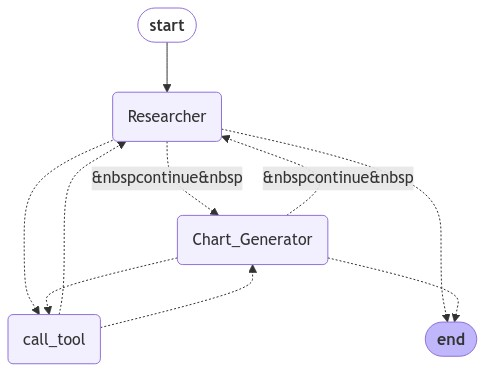

In [58]:
# 可视化图
from IPython.display import Image, display

try:
    display(
        Image(
            graph.get_graph(xray=True).draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"Error generating graph: {e}")

In [59]:
events = graph.stream(
    {
        "messages": [
            HumanMessage(
                content="Obtain the GDP of the United States from 2000 to 2020, "
            "and then plot a line chart with Python. End the task after generating the chart。"
            )
        ],
    },
    # 设置最大递归限制
    {"recursion_limit": 20},
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()  # 打印消息内容

================================ Human Message =================================

Obtain the GDP of the United States from 2000 to 2020, and then plot a line chart with Python. End the task after generating the chart。
================================== Ai Message ==================================
Name: Researcher

To accomplish this task, I will first search for the GDP data of the United States from 2000 to 2020. After obtaining the data, I will provide instructions on how to plot a line chart using Python. Let's start by searching for the GDP data.
Tool Calls:
  tavily_search_results_json (call_ddc2eb94ff6b4ccd8582af)
 Call ID: call_ddc2eb94ff6b4ccd8582af
  Args:
    query: GDP of the United States from 2000 to 2020
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://www.multpl.com/us-gdp/table/by-year", "content": "US GDP table by year, historic, and current data. Current US GDP is 29.02 trillion. S&P 

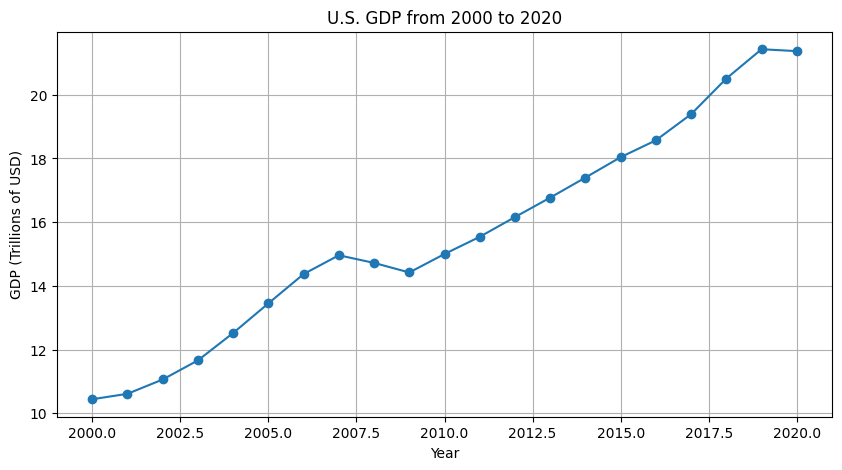

In [90]:
import matplotlib.pyplot as plt

# GDP data from 2000 to 2020
years = list(range(2000, 2021))
gdp_values = [
    10.44, 10.61, 11.06, 11.66, 12.52, 13.45, 14.37, 14.96, 14.72, 14.42,
    15.00, 15.54, 16.16, 16.77, 17.40, 18.04, 18.57, 19.39, 20.51, 21.43, 21.37
]

# Plotting the GDP data
plt.figure(figsize=(10, 5))
plt.plot(years, gdp_values, marker='o', linestyle='-')
plt.title('U.S. GDP from 2000 to 2020')
plt.xlabel('Year')
plt.ylabel('GDP (Trillions of USD)')
plt.grid(True)
plt.show()

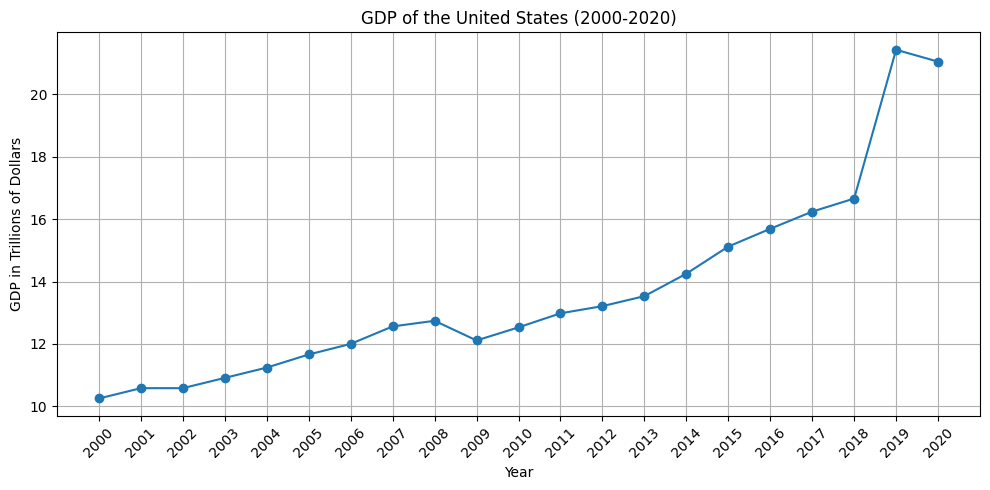

In [109]:
import matplotlib.pyplot as plt

# GDP data for the United States from 2000 to 2020
years = list(range(2000, 2021))
gdp_values = [
    10.25, 10.58, 10.58, 10.91, 11.24, 11.66, 
    12.00, 12.56, 12.74, 12.11, 12.53, 12.98, 
    13.21, 13.53, 14.25, 15.12, 15.69, 16.24, 
    16.66, 21.43, 21.05
]

# Create a line chart
plt.figure(figsize=(10, 5))
plt.plot(years, gdp_values, marker='o')
plt.title('GDP of the United States (2000-2020)')
plt.xlabel('Year')
plt.ylabel('GDP in Trillions of Dollars')
plt.xticks(years, rotation=45)
plt.grid()
plt.tight_layout()

# Show the plot
plt.show()

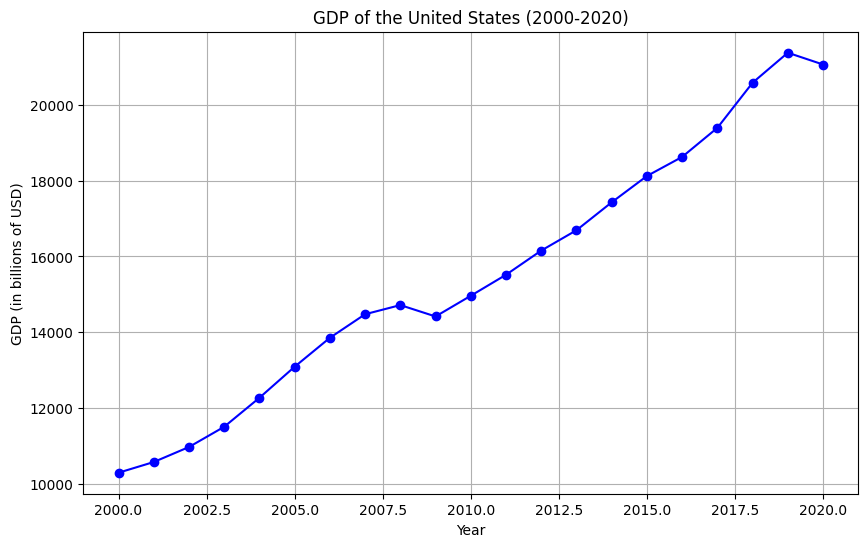

In [129]:
import pandas as pd
import matplotlib.pyplot as plt

# GDP data for the United States from 2000 to 2020 in current US dollars (in billions)
gdp_data = {
    2000: 10300.0,
    2001: 10581.8,
    2002: 10977.5,
    2003: 11510.7,
    2004: 12274.9,
    2005: 13093.7,
    2006: 13855.9,
    2007: 14477.6,
    2008: 14718.6,
    2009: 14418.7,
    2010: 14964.4,
    2011: 15517.9,
    2012: 16155.3,
    2013: 16691.5,
    2014: 17427.6,
    2015: 18120.7,
    2016: 18624.5,
    2017: 19390.6,
    2018: 20580.2,
    2019: 21370.9,
    2020: 21060.4
}

# Convert the data into a DataFrame
df = pd.DataFrame(list(gdp_data.items()), columns=['Year', 'GDP'])

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(df['Year'], df['GDP'], marker='o', linestyle='-', color='b')
plt.title('GDP of the United States (2000-2020)')
plt.xlabel('Year')
plt.ylabel('GDP (in billions of USD)')
plt.grid(True)
plt.show()

### 大模型执行比较结果

| 大模型 | 结果 |
| --- | --- |
| 智谱：glm-4-plus | 提取不到gdp数据，没生成能够跑的代码 |
| qwen: qwen-plus | 没法执行代码画图，只给了代码 |
| qwen: qwen-max | 没法执行代码画图，只给了代码，并且给出代码之后不会自动结束，循环了几次 |
| openai:  gpt-4o-mini | 没法执行代码画图，只给了代码 |
| deepseek: deepseek-chat | 没法执行代码画图，只给了代码 |

## 2.将 Chart Generator 替换为其他功能智能体（如 table_generator），为其设计提示词，然后运行查看生成结果。

In [ ]:
参见另外一个notebook

## 3.（可选）优化研究智能体 Researcher 提示词和路由函数 route 跳转逻辑，提升图表生成的成功率。